In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

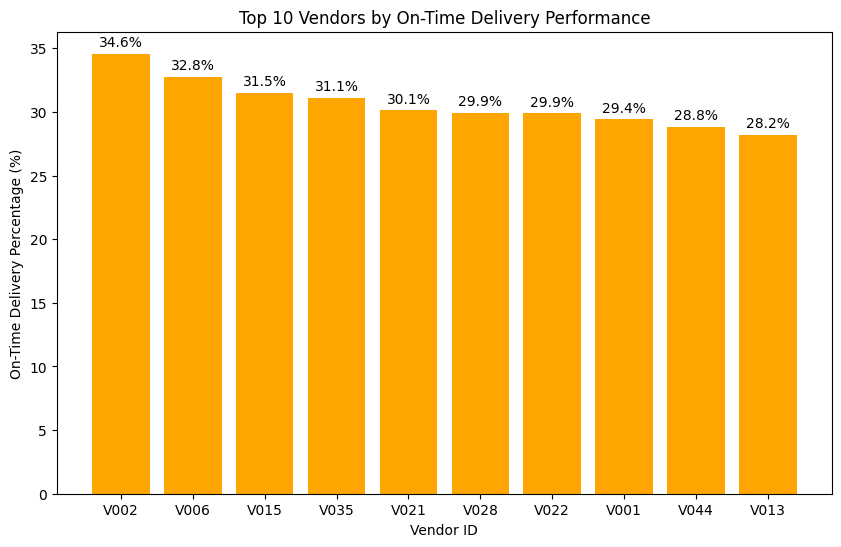

In [5]:
conn = sqlite3.connect(r'..\..\supply_chain.db')
query = """
    SELECT 
        vendor_id,
        on_time_delivery_percentage
    FROM aggregated_vendor_kpis
    WHERE insert_ts = (
        SELECT MAX(insert_ts) FROM aggregated_vendor_kpis
    )
    ORDER BY on_time_delivery_percentage DESC
    LIMIT 10;
"""

try:
    df = pd.read_sql(query, conn)

    if df.empty:
        print("No data found to transfer.")

    plt.figure(figsize=(10, 6))
    bars = plt.bar(df['vendor_id'], df['on_time_delivery_percentage'], color='orange')
    plt.bar_label(bars, padding=3, fmt='%.1f%%')
    
    plt.xlabel('Vendor ID')
    plt.ylabel('On-Time Delivery Percentage (%)')
    plt.title('Top 10 Vendors by On-Time Delivery Performance')
        
    plt.show()

except Exception as e:
    print(f"Error during load: {e}")
finally:
    conn.close()

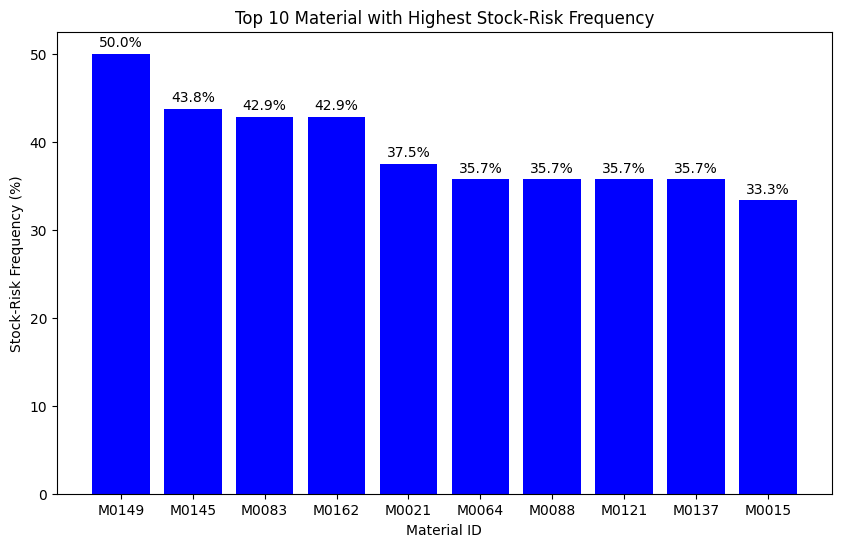

In [6]:
conn = sqlite3.connect(r'..\..\supply_chain.db')
query = """
    SELECT 
        *
    FROM material_inventory_risk
    WHERE insert_ts = (
        SELECT MAX(insert_ts) FROM material_inventory_risk
    )
    ORDER BY pct_time_below_safety DESC
    LIMIT 10;
"""

try:
    df = pd.read_sql(query, conn)
    
    if df.empty:
        print("No data found to transfer.")

    plt.figure(figsize=(10, 6))
    bars = plt.bar(df['material_id'], df['pct_time_below_safety'], color='blue')
    plt.bar_label(bars, padding=3, fmt='%.1f%%')
    
    plt.xlabel('Material ID')
    plt.ylabel('Stock-Risk Frequency (%)')
    plt.title('Top 10 Material with Highest Stock-Risk Frequency')

    plt.show()

except Exception as e:
    print(f"Error during load: {e}")
finally:
    conn.close()